In [1]:
import mnist
import torch
import numpy as np
import matplotlib.pyplot as plt

In [2]:
DATA = mnist.train_images()
LABELS = mnist.train_labels()
MEAN = DATA.mean()
STD = DATA.std()
DATA = 2*(DATA/256-0.5)

def sample_mnist(N, labels = False):
    idx = np.random.randint(0,len(DATA), size = (N,))
    if not labels:
        return torch.FloatTensor(DATA[idx])
    return torch.FloatTensor(DATA[idx]), LABELS[idx]


In [3]:
class VAE(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.inference = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(784,200),
            torch.nn.ReLU(),
            torch.nn.Linear(200,200),
            torch.nn.ReLU(),
            torch.nn.Linear(200,200),
            torch.nn.ReLU(),
            torch.nn.Linear(200,4),
        )

        self.generation = torch.nn.Sequential(
            torch.nn.Linear(2,200),
            torch.nn.ReLU(),
            torch.nn.Linear(200,200),
            torch.nn.ReLU(),
            torch.nn.Linear(200,200),
            torch.nn.ReLU(),
            torch.nn.Linear(200,784),
            torch.nn.Tanh(),
            torch.nn.Unflatten(-1,(28,28))
        )
    
    def forward(self, x, noise):
        post = self.inference(x)
        post_mean_z, post_logstd_z = post[:,:2],post[:,2:]

        post_std_z = post_logstd_z.exp()
        z_sample = post_mean_z + post_std_z * torch.randn(post_mean_z.shape)

        pred = self.generation(z_sample)
        
        return pred, z_sample, post_mean_z, post_logstd_z
        


def kl_divergence(post_mean, post_logstd):
    latent_dim = post_mean.shape[-1]
    delta = post_mean
    
    delta_sq = delta.pow(2).sum(axis=-1)
    log_det_trace = post_logstd.sum(axis=-1)
    trace = post_logstd.exp().sum(axis=-1)
    
    return 0.5*(trace + delta_sq  - latent_dim - log_det_trace)

def train_step(model, x, noise, beta = 0.001):

    # ELBO = E_q(z|x) log p(x|z)p(z)/q(z|x) = E_q(z|x) log p(x|z) - E_q(z|x) q(z|x)/p(z) =  E_q(z|x) log p(x|z) - DKL
    #-ELBO = E_q(z|x) -log p(x|z) + DKL = reco_loss + DKL

    pred, z_sample, post_mean_z, post_logstd_z = model(x,noise)
    reco = torch.nn.functional.mse_loss(pred, x, reduction='mean')
    kl_div = kl_divergence(post_mean_z, post_logstd_z).mean()

    #either do reduction = sum and beta = O(1)
    #or do reduction = mean and beta small
    loss = reco + beta * kl_div
    
    return loss, reco, post_mean_z

In [4]:
kl_divergence(-torch.ones(1,2), -torch.ones(1,2)).mean()

tensor(1.3679)

In [9]:
def train_vae(beta):
    model = VAE()
    opt = torch.optim.Adam(model.parameters(), 1e-3)

    for i in range(3000):
        X = sample_mnist(1000)
        loss,_,_ = train_step(model, X, torch.randn(X.shape[0],2), beta)
        loss.backward()
        if i % 1000 == 0:
            print(i,float(loss))
        opt.step()
        opt.zero_grad()
    return model

models = [train_vae(lr) for lr in [0, 0.0002, 0.001, 0.01, 1.0]]

0 0.9202393293380737
1000 0.15787555277347565
2000 0.14530394971370697
0 0.9284346103668213
1000 0.16140590608119965
2000 0.15364493429660797
0 0.9261818528175354
1000 0.17303085327148438
2000 0.15767483413219452
0 0.9332593083381653
1000 0.20308901369571686
2000 0.19213970005512238
0 0.9437506198883057
1000 0.26360800862312317
2000 0.26810556650161743


In [10]:
def sample_autoencoder(model):
    with torch.no_grad():
        _x,_y = sample_mnist(10000, labels=True)
        _r, _z, _mz, _ls = model(_x,torch.randn(1000,2))
    return _z,_y

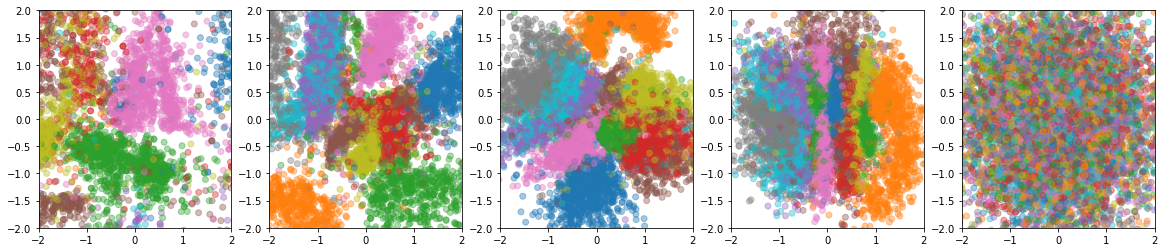

In [14]:
f,axarr = plt.subplots(1,5)
for ax,model in zip(axarr.ravel(), models):
    _z,_y = sample_autoencoder(model)
    ax.scatter(_z[:,0],_z[:,1], c = _y, alpha = 0.4, cmap = 'tab10', vmin = 0, vmax = 10)
    ax.set_xlim(-2,2)
    ax.set_ylim(-2,2)
    
f.set_size_inches(20,4)

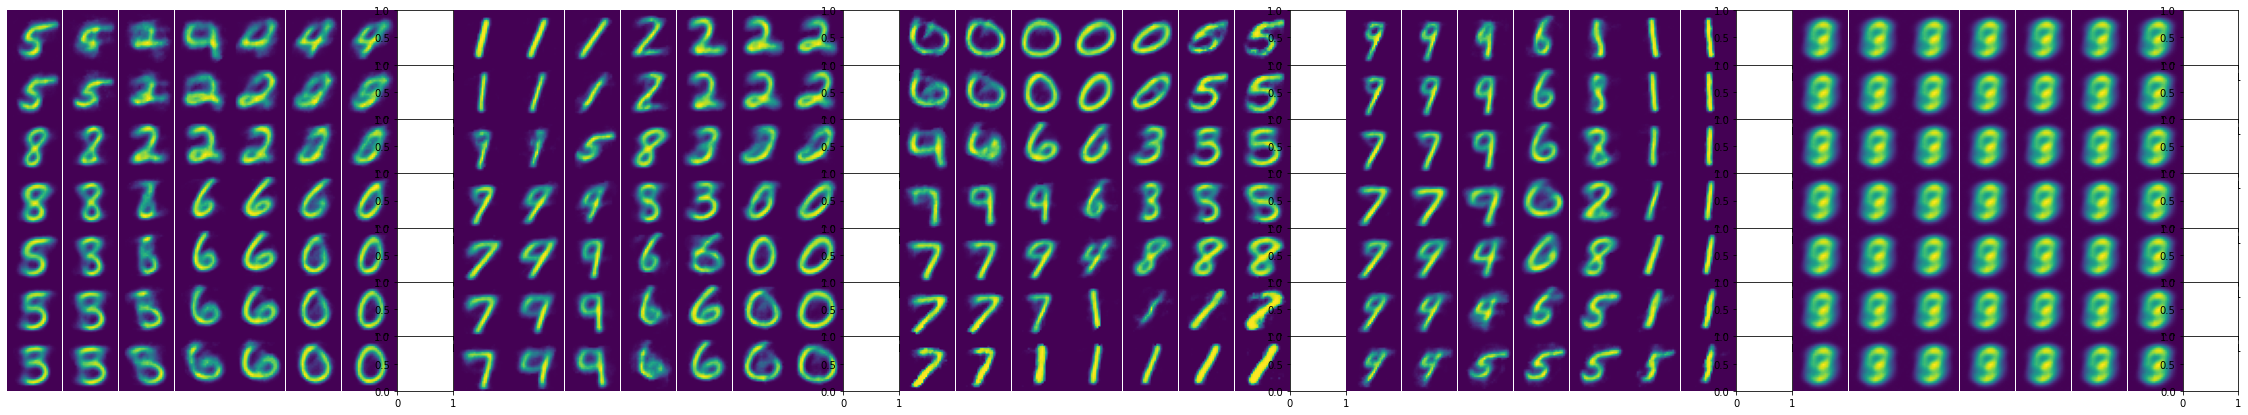

In [13]:
def plot_decode(model,axarr):
    axarr = axarr[:,:-1]
    z = np.mgrid[-2:2:7j,-2:2:7j]
    with torch.no_grad():
        imgs = model.generation(torch.FloatTensor(np.swapaxes(z,0,-1).reshape(-1,2)))
    plt.subplots_adjust(wspace = 0, hspace = 0)
    for ax,img in zip(axarr.ravel(), imgs):
        ax.imshow(img)
        ax.axis('off')
    
f,axarr = plt.subplots(7,5*8)
for i,model in enumerate(models):
    plot_decode(model,axarr[:,i*8:(i+1)*8])
f.set_size_inches(5*8,7)